# 🇬🇧 Predicting London Airbnb Prices: A Machine Learning Approach

**Executive Summary:**
The London short-term rental market is highly competitive and deeply influenced by location, property size, and specific amenities. The goal of this project is to build a Machine Learning pipeline capable of predicting the nightly price of a London Airbnb. 

By analyzing over 80,000 real-world listings, we will engineer features, visualize geospatial trends, and train an optimized Random Forest algorithm to understand the hidden patterns of the London real estate market.

---

In [1]:
# 1. Data Manipulation (The heavy lifters)
import pandas as pd
import numpy as np

# 2. Data Visualization (The chart makers)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning (We will add more of Scikit-Learn later, but let's prep it)
from sklearn.model_selection import train_test_split

# 4. Notebook Formatting (Makes our charts look nice and ignores annoying warnings)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Phase 1: Data Ingestion & Cleaning
Real-world data is inherently messy. Before we can train any algorithms, we need to sanitize our dataset. 

In this phase, we:
* Load the raw dataset into a Pandas DataFrame.
* Identify and remove irrelevant columns that do not contribute to predictive power (e.g., host IDs, scraping dates).
* Handle missing values by isolating the crucial features and dropping rows with incomplete structural data.

In [2]:
filepath = "C:/Users/neelb/OneDrive/Desktop/Airbnb_London_Project/airbnb_london_dataset.csv"
print("Filepath saved!")

Filepath saved!


In [3]:
df = pd.read_csv(filepath)
print("file read successfully!")

file read successfully!


In [4]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,92644,https://www.airbnb.com/rooms/92644,20230906022807,2023-09-06,city scrape,Rental unit in Earlsfield · ★4.57 · 1 bedroom ...,<b>The space</b><br />Hi everyone! I have 2 ro...,NaN,https://a0.muscache.com/pictures/715127/85bdb4...,498201,...,4.67,4.53,4.68,NaN,t,1,0,1,0,1.45
1,93015,https://www.airbnb.com/rooms/93015,20230906022807,2023-09-06,city scrape,Rental unit in Hammersmith · ★4.82 · 2 bedroom...,Gorgeous 2 bed ground floor apartment with per...,A bit of history about the W14 area: <br />Com...,https://a0.muscache.com/pictures/865937ec-ee56...,499704,...,4.88,4.85,4.74,NaN,f,1,1,0,0,0.27
2,13913,https://www.airbnb.com/rooms/13913,20230906022807,2023-09-06,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.82,4.69,4.69,NaN,f,2,1,1,0,0.26
3,15400,https://www.airbnb.com/rooms/15400,20230906022807,2023-09-06,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.83,4.93,4.74,NaN,f,1,1,0,0,0.56
4,93734,https://www.airbnb.com/rooms/93734,20230906022807,2023-09-07,city scrape,Condo in London · ★4.62 · 1 bedroom · 1 bed · ...,<b>During your stay</b><br />I’m a professiona...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,497514,...,4.81,4.64,4.67,NaN,f,1,0,1,0,1.21


In [5]:
df.shape

(87946, 75)

In [6]:
df.isnull().sum().sort_values(ascending=False).head(20)

neighbourhood_group_cleansed    87946
bathrooms                       87946
calendar_updated                87946
license                         87945
host_about                      42040
neighborhood_overview           40756
neighbourhood                   40755
host_neighbourhood              39867
bedrooms                        32774
host_response_time              28918
host_response_rate              28918
host_acceptance_rate            25188
review_scores_value             23126
review_scores_checkin           23125
review_scores_location          23125
review_scores_communication     23095
review_scores_accuracy          23093
review_scores_cleanliness       23081
last_review                     22158
first_review                    22158
dtype: int64

In [7]:
dead_weight_columns = ['neighbourhood_group_cleansed', 'bathrooms', 'calendar_updated', 'license']
df.drop(columns=dead_weight_columns, inplace=True)
print("Columns dropped!")

Columns dropped!


In [8]:
df.shape

(87946, 71)

In [9]:
df[['price']].head(10)

,price
0,$42.00
1,$175.00
2,$79.00
3,$150.00
4,$46.00
5,$476.00
6,$371.00
7,$250.00
8,$75.00
9,$29.00


In [10]:
df['price'] = df['price'].str.replace('$','', regex=False)
df['price'] = df['price'].str.replace(',','', regex=False)
df['price'] = df['price'].astype(float)
print('Price column cleaned and datatype changed to float!')

Price column cleaned and datatype changed to float!


In [11]:
df[['price']].head(10)

,price
0,42.0
1,175.0
2,79.0
3,150.0
4,46.0
5,476.0
6,371.0
7,250.0
8,75.0
9,29.0


In [12]:
df['price'].describe()

count    87946.000000
mean       181.349817
std        486.174310
min          0.000000
25%         63.000000
50%        110.000000
75%        193.000000
max      80100.000000
Name: price, dtype: float64

In [13]:
# Filtering the price dataset to only include realistic prices
df = df[(df['price'] >=10) & (df['price'] <= 1000)]
print("Rows remaining after removing the outliers: ", df.shape[0])

Rows remaining after removing the outliers:  86543


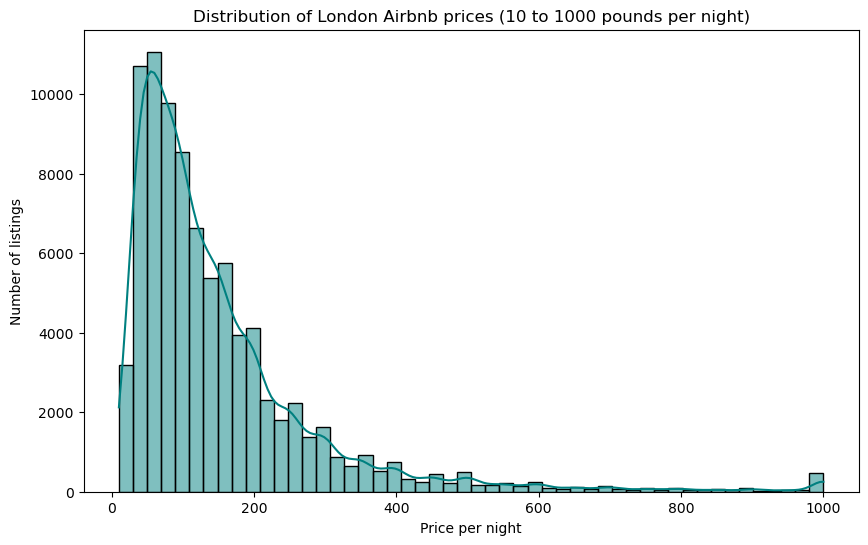

In [14]:
# Visualising the clean price distribution
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True, color='teal')
plt.title('Distribution of London Airbnb prices (10 to 1000 pounds per night)')
plt.xlabel('Price per night')
plt.ylabel('Number of listings')
plt.show()





## Phase 2: Feature Engineering
Machine Learning models require data to be presented in specific mathematical formats. 

1. **Log Transformation:** Real estate prices are heavily right-skewed (a few ultra-luxury mansions drag the average up). We apply a logarithmic transformation to the `price` column to normalize the distribution, making it easier for the algorithm to learn.
2. **One-Hot Encoding:** Models cannot read text (like "Westminster" or "Private room"). We use Pandas `get_dummies` to convert these categorical text columns into a binary matrix (0s and 1s) so the algorithm can mathematically weigh them.

In [15]:
df['price_log'] = np.log1p(df['price'])
df['price_log'].head()

0    3.761200
1    5.170484
2    4.382027
3    5.017280
4    3.850148
Name: price_log, dtype: float64

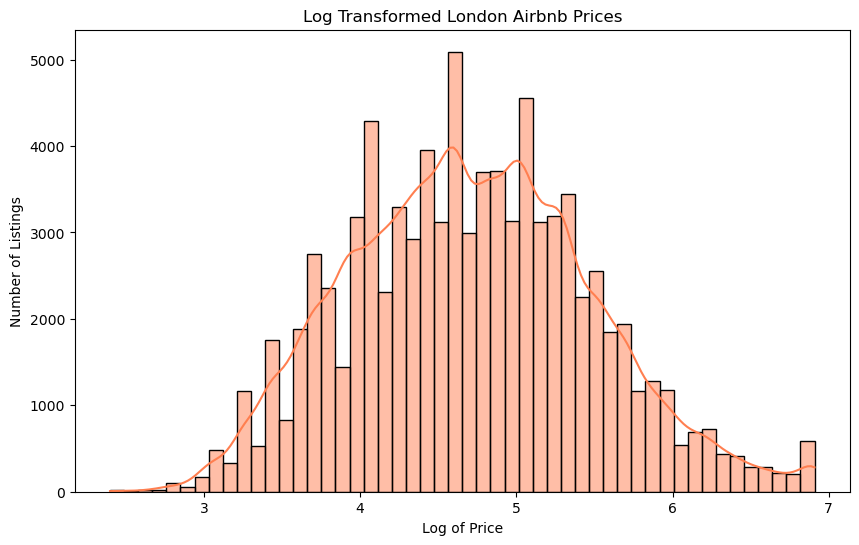

In [16]:
# Visualising the new transformed data
plt.figure(figsize=(10,6))
sns.histplot(df['price_log'], bins=50, kde=True, color='coral')
plt.title('Log Transformed London Airbnb Prices')
plt.xlabel('Log of Price')
plt.ylabel('Number of Listings')
plt.show()

In [17]:
# Selecting the features to do the analysis on
selected_features = ['latitude', 'longitude', 'neighbourhood_cleansed', 'room_type', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'price_log']

# Slicing the dataframe
df = df[selected_features]

# Checking for missing values
print(df.isnull().sum())

latitude                      0
longitude                     0
neighbourhood_cleansed        0
room_type                     0
accommodates                  0
bedrooms                  32519
beds                       1116
number_of_reviews             0
review_scores_rating      21335
price_log                     0
dtype: int64


In [18]:
# Filling missing values of bedrooms with the median
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

# Filling missing values of beds with the median
df['beds'] = df['beds'].fillna(df['bedrooms'].median())

# Filling missing values of review scores with a median rating
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())

# Checking if any missing values left
print(df.isnull().sum())

latitude                  0
longitude                 0
neighbourhood_cleansed    0
room_type                 0
accommodates              0
bedrooms                  0
beds                      0
number_of_reviews         0
review_scores_rating      0
price_log                 0
dtype: int64


In [19]:
df.dtypes

latitude                  float64
longitude                 float64
neighbourhood_cleansed     object
room_type                  object
accommodates                int64
bedrooms                  float64
beds                      float64
number_of_reviews           int64
review_scores_rating      float64
price_log                 float64
dtype: object

In [20]:
# Converting our categorical columns into seperate columns by creating dummy variables
df_dummy = pd.get_dummies(df, columns=['neighbourhood_cleansed', 'room_type'], drop_first=True)

# Let's check
print('Old shape: ', df.shape)
print('New shape: ', df_dummy.shape)

Old shape:  (86543, 10)
New shape:  (86543, 43)


In [21]:
df_dummy.head()

,latitude,longitude,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating,price_log,neighbourhood_cleansed_Barnet,neighbourhood_cleansed_Bexley,...,neighbourhood_cleansed_Richmond upon Thames,neighbourhood_cleansed_Southwark,neighbourhood_cleansed_Sutton,neighbourhood_cleansed_Tower Hamlets,neighbourhood_cleansed_Waltham Forest,neighbourhood_cleansed_Wandsworth,neighbourhood_cleansed_Westminster,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,51.44201,-0.18739,2,2.0,2.0,216,4.57,3.761200,False,False,...,False,False,False,False,False,True,False,False,True,False
1,51.49993,-0.21707,5,2.0,3.0,38,4.82,5.170484,False,False,...,False,False,False,False,False,False,False,False,False,False
2,51.56861,-0.11270,1,2.0,1.0,41,4.80,4.382027,False,False,...,False,False,False,False,False,False,False,False,True,False
3,51.48780,-0.16813,2,1.0,1.0,94,4.80,5.017280,False,False,...,False,False,False,False,False,False,False,False,False,False
4,51.47618,0.01442,2,2.0,1.0,180,4.62,3.850148,False,False,...,False,False,False,False,False,False,False,False,True,False


In [22]:
df_dummy['beds'] = df_dummy['beds'].astype(float)

In [23]:
df_dummy.reset_index()
df_dummy.head()

,latitude,longitude,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating,price_log,neighbourhood_cleansed_Barnet,neighbourhood_cleansed_Bexley,...,neighbourhood_cleansed_Richmond upon Thames,neighbourhood_cleansed_Southwark,neighbourhood_cleansed_Sutton,neighbourhood_cleansed_Tower Hamlets,neighbourhood_cleansed_Waltham Forest,neighbourhood_cleansed_Wandsworth,neighbourhood_cleansed_Westminster,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,51.44201,-0.18739,2,2.0,2.0,216,4.57,3.761200,False,False,...,False,False,False,False,False,True,False,False,True,False
1,51.49993,-0.21707,5,2.0,3.0,38,4.82,5.170484,False,False,...,False,False,False,False,False,False,False,False,False,False
2,51.56861,-0.11270,1,2.0,1.0,41,4.80,4.382027,False,False,...,False,False,False,False,False,False,False,False,True,False
3,51.48780,-0.16813,2,1.0,1.0,94,4.80,5.017280,False,False,...,False,False,False,False,False,False,False,False,False,False
4,51.47618,0.01442,2,2.0,1.0,180,4.62,3.850148,False,False,...,False,False,False,False,False,False,False,False,True,False


## Phase 3: Exploratory Data Analysis (EDA) & Geospatial Mapping
Before modeling, we need to understand the relationships between our variables. 

First, we calculate the correlation between our engineered features and the target variable (Log Price) to identify the strongest price drivers. Next, we aggregate the data and map the actual median prices onto a GeoJSON map of London to visually confirm the geospatial distribution of wealth across the city's boroughs.

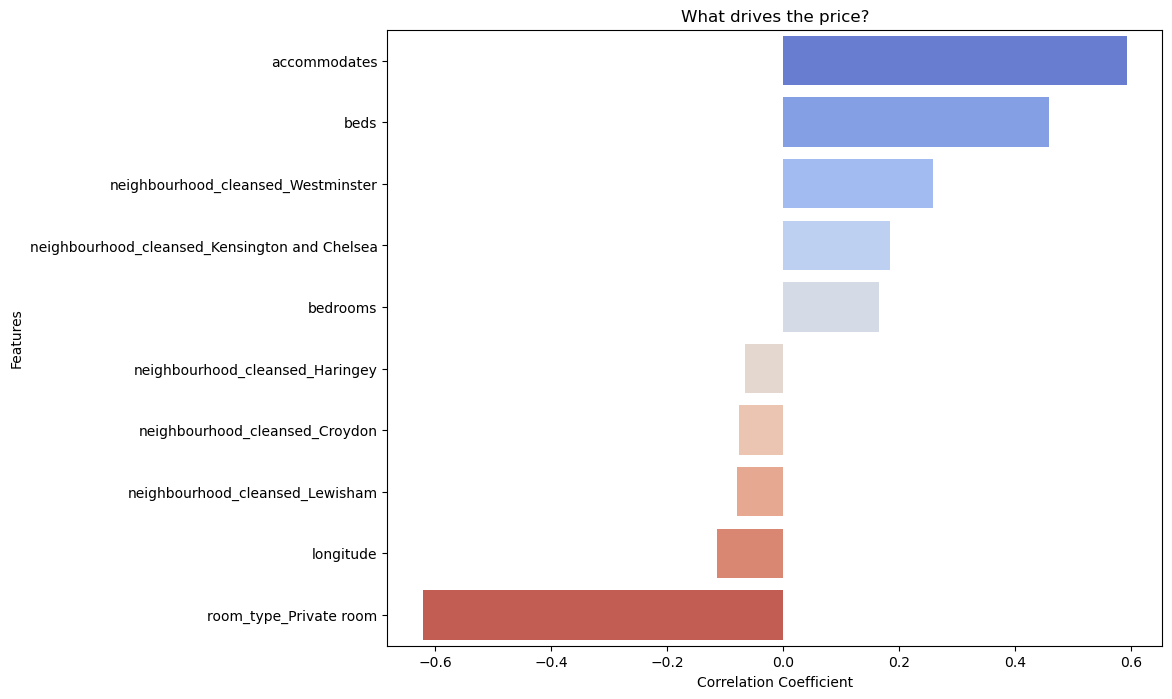

In [24]:
# Calculating correlations of all features against our target variable (price_log)
correlations = df_dummy.corr()['price_log'].sort_values(ascending=False)

# Dropping price_log from the list (Since it will perfectly correlate with itself)
correlations = correlations.drop('price_log')

# Plot top 5 positive and negative correlations
top_cor = pd.concat([correlations.head(5), correlations.tail(5)])

plt.figure(figsize=(10,8))
sns.barplot(x=top_cor.values, y=top_cor.index, palette='coolwarm')
plt.title("What drives the price?")
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()

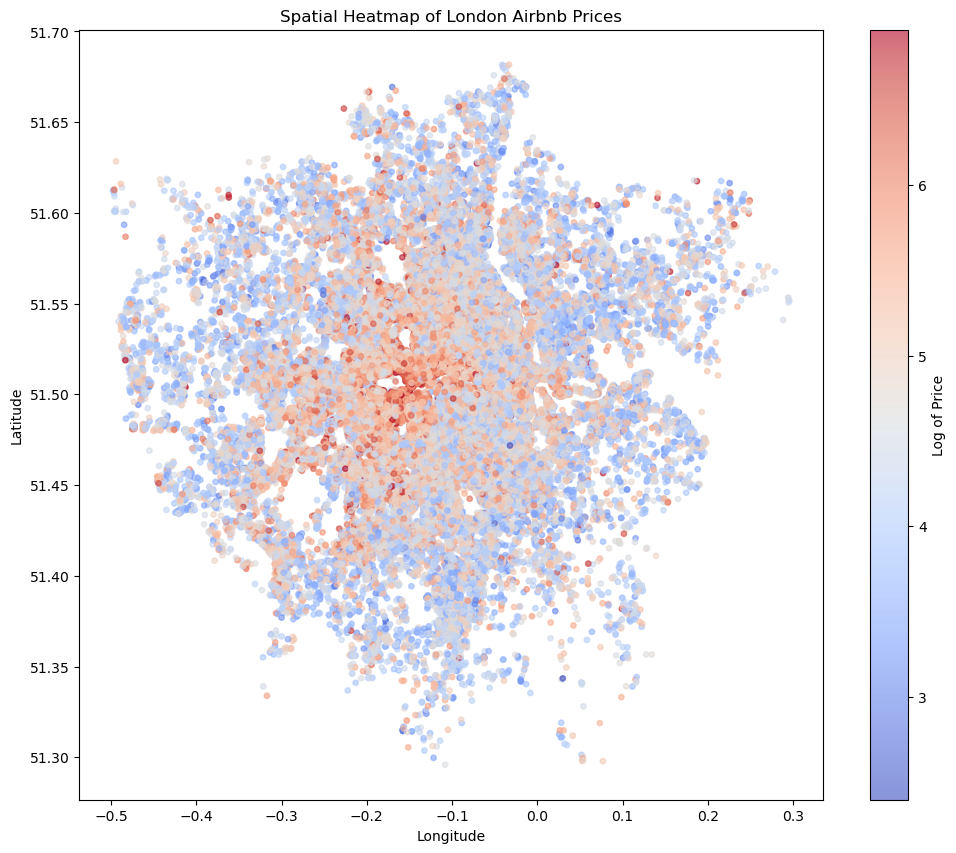

In [25]:
# Creating a spatial scatter plot using latitude and longitude
plt.figure(figsize=(12,10))

# Using price_log for the color scale
scatter = plt.scatter(x=df_dummy['longitude'],
                      y=df_dummy['latitude'],
                      c=df_dummy['price_log'], # Color by Price
                      cmap='coolwarm',         # Blue is cheap, Red is expensive
                      alpha=0.6,               
                      s=15)

plt.colorbar(scatter, label='Log of Price')
plt.title('Spatial Heatmap of London Airbnb Prices')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [26]:
import numpy as np
import plotly.express as px
import requests  # <-- We need to import requests again!

# 1. Download the shapefile (GeoJSON) of London's boroughs
url = "https://raw.githubusercontent.com/radoi90/housequest-data/master/london_boroughs.geojson"
london_geojson = requests.get(url).json()

# 2. Group the data and get the median log price
borough_summary = df.groupby('neighbourhood_cleansed')['price_log'].median().reset_index()

# 3. Reverse the log transformation to get actual real-world prices
borough_summary['Actual_Price_£'] = np.exp(borough_summary['price_log'])

# 4. Draw the Map using Mapbox 
fig = px.choropleth_mapbox(
    borough_summary,
    geojson=london_geojson,
    locations='neighbourhood_cleansed', 
    featureidkey='properties.name',     
    color='Actual_Price_£',             
    color_continuous_scale="Reds",      
    mapbox_style="carto-positron",      
    zoom=9,                             
    center={"lat": 51.5074, "lon": -0.1278}, 
    opacity=0.7,                        
    title="Average London Airbnb Prices by Borough (£)",
    height=700  
)

# 5. Remove the giant white borders around the map
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig.show(renderer='iframe')

## Phase 4: Baseline Modeling (Linear Regression)
To establish a baseline, we first split our data into an 80% Training set and a 20% Testing set to prevent data leakage. We then train a standard Linear Regression model. 

While Linear Regression is highly interpretable, it assumes a strict linear relationship between features and price, which often misses the nuances of real-world human behavior in the housing market.

In [27]:
# Splitting the selected data for training and testing
# Define X (Features) and Y (Target Variable)
X = df_dummy.drop('price_log', axis=1)
Y = df_dummy['price_log']

# Splitting the data (80/20)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Checking to make sure it worked
print("Training Data (X_Train): ", x_train.shape)
print("Testing Data (X_Test): ", x_test.shape)

Training Data (X_Train):  (69234, 42)
Testing Data (X_Test):  (17309, 42)


In [28]:
# Importing scikit learn models for training and testing our data
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Initialise the model
lm = LinearRegression()

# Train the model
lm.fit(x_train,y_train)

# Predict using the testing data
y_predict = lm.predict(x_test)

# R-Squared Score
score = r2_score(y_test, y_predict)
print(score)


0.5805176977962063


In [29]:
# Interpreting the Model
# Creating a Dataframe matching our feature names to the models learned weights
imp_df = pd.DataFrame({'Feature': x_train.columns, 'Impact on Price': lm.coef_})

# Sorting the data to see the extremes
#Top 5 features that increase the price
print("--- Top 5 Features that Increase Price ---")
print(imp_df.sort_values(by='Impact on Price', ascending=False).head(5))

# Top 5 features that decrease the price
print("\n--- Top 5 Features that Decrease Price ---")
print(imp_df.sort_values(by='Impact on Price', ascending=True).head(5))

--- Top 5 Features that Increase Price ---
                                          Feature  Impact on Price
38             neighbourhood_cleansed_Westminster         0.884197
25  neighbourhood_cleansed_Kensington and Chelsea         0.832616
1                                       longitude         0.784530
12          neighbourhood_cleansed_City of London         0.734380
11                  neighbourhood_cleansed_Camden         0.599821

--- Top 5 Features that Decrease Price ---
                            Feature  Impact on Price
41            room_type_Shared room        -0.907250
40           room_type_Private room        -0.621206
0                          latitude        -0.591971
8     neighbourhood_cleansed_Bexley        -0.101588
21  neighbourhood_cleansed_Havering        -0.041773


## Phase 5: Advanced Modeling & Hyperparameter Tuning
To capture the non-linear "quirks" of the London housing market, we upgrade our algorithm to an ensemble method: the **Random Forest Regressor**. 

Instead of guessing the optimal architecture for this model, we deploy `GridSearchCV`. This creates a testing matrix that trains multiple versions of the Random Forest using different combinations of trees and depths, utilizing Cross-Validation to guarantee we select the absolute most accurate mathematical model possible.

In [30]:
# Importing the Random Forest model to upgrade our model
from sklearn.ensemble import RandomForestRegressor

# Initialise the Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
print("Planting the trees and training our model!")

# Training the new model
rf.fit(x_train, y_train)

# Predict and check the score
rf_predict = rf.predict(x_test)
rf_score = r2_score(y_test, rf_predict)

print(rf_score)

Planting the trees and training our model!
0.6671513522203656


In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Defining the dials we want the computer to test
grid_param = {'n_estimators' : [100, 200], 'max_depth' : [15, 25]}

# Initialising the blank, fresh random forest
rf_base = RandomForestRegressor(random_state=42)

# Set up the GridSearchCV
print("Setting up the arena... preparing to train 12 different forests")
grid_search = GridSearchCV(estimator=rf_base, param_grid=grid_param, cv=3, n_jobs=1, verbose=2)

# Fit the model
grid_search.fit(x_train, y_train)

# Get the result
print(f"Best Parameters Found: {grid_search.best_params_}")

# Testing our winning model's accuracy on the hidden 20% testing data
best_rf = grid_search.best_estimator_
best_predictions = best_rf.predict(x_test)
best_score = r2_score(y_test, best_predictions)

print(f'Old Forest Score: {rf_score}')
print(f"New Tuned Model score: {best_score}")

               

Setting up the arena... preparing to train 12 different forests
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END .....................max_depth=15, n_estimators=100; total time=  19.8s
[CV] END .....................max_depth=15, n_estimators=100; total time=  19.7s
[CV] END .....................max_depth=15, n_estimators=100; total time=  19.7s
[CV] END .....................max_depth=15, n_estimators=200; total time=  39.4s
[CV] END .....................max_depth=15, n_estimators=200; total time=  39.3s
[CV] END .....................max_depth=15, n_estimators=200; total time=  39.5s
[CV] END .....................max_depth=25, n_estimators=100; total time=  27.0s
[CV] END .....................max_depth=25, n_estimators=100; total time=  26.6s
[CV] END .....................max_depth=25, n_estimators=100; total time=  27.3s
[CV] END .....................max_depth=25, n_estimators=200; total time=  54.1s
[CV] END .....................max_depth=25, n_estimators=200; tota

---
## Conclusion & Business Impact

**Final Model Performance:** Our tuned Random Forest achieved an R-squared accuracy score of **~66.7%**. 

**Business Takeaways:**
1. **Size Dictates Baseline:** Property capacity (accommodates, beds, bedrooms) is the absolute strongest baseline predictor of a high nightly rate. 
2. **The Privacy Premium:** Offering a "Shared Room" or "Private Room" severely penalizes the nightly rate compared to an "Entire Home".
3. **Location Multiplier:** Central, historic, and financial districts (Westminster, Kensington & Chelsea, City of London) act as massive multipliers on the baseline price.

**Future Improvements:**
To push the model's accuracy beyond the ~67% "data ceiling" achieved here, future iterations would require scraping additional data vectors, such as host response rates, sentiment analysis of written user reviews, and deep learning image classification of the property photos to quantify "luxury" interior design.